## Simulation experiment 1
2026-05-03

Motivation: 
The M249 is the only gun that allows the drone to stabilize at an angle while continuously firing (approx. 48 degrees downwards). 

Objective: 
See whether or not an RL agent will control the drone (M249) to always to go that angle. 

Stats: 
M249_saw
No wind

Notes: 
***I should probably remove some inputs from the environment that give it an unfair advantage (wind)***

In [1]:
import argparse
import time
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

from drone_sim.control.controller import quat_to_euler, wrap_pi
from drone_sim.rl.custom_envs import SimpleRewardEnv

import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

In [ ]:
# Loading model to continue training
model = PPO.load("ppo_e1_a", env = SimpleRewardEnv())

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
# Parallel environments
#vec_env = make_vec_env(SimpleRewardEnv, n_envs=4)

#model = PPO("MlpPolicy", vec_env, verbose=1)
model.learn(total_timesteps=1000000, reset_num_timesteps=False, learning_rate=0.0001)
model.save("ppo_e1_a")

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 25.7     |
|    ep_rew_mean     | -0.648   |
| time/              |          |
|    fps             | 821      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 509952   |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 26.6        |
|    ep_rew_mean          | -0.71       |
| time/                   |             |
|    fps                  | 679         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 512000      |
| train/                  |             |
|    approx_kl            | 0.016934512 |
|    clip_fraction        | 0.189       |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.48       |
|    explained_variance   | 0.378       |
|    learning_rate        | 0.

In [ ]:
model = PPO.load("ppo_e1_a")

obs = vec_env.reset()
while True:
    action, _states = model.predict(obs)
    obs, rewards, dones, info = vec_env.step(action)
    vec_env.render("human")

In [27]:
def run_episode(env, model, render: bool = False, print_every: int = 20):
    """Run one full episode, print rolling reward, return per-step rewards."""
    obs, info = env.reset()
    rewards = []
    cum = 0.0
    if render:
        env.render()

    print(f"{'step':>5}  {'reward':>8}  {'cum':>10}  {'hits':>5}  {'ammo':>4}")
    print("-" * 44)
    while True:
        action = model.predict(obs, deterministic=True)[0]
        print(action)
        obs, r, terminated, truncated, info = env.step(action)
        rewards.append(float(r))
        cum += r
        if render:
            env.render()

        step = len(rewards)
        if step % print_every == 0 or terminated or truncated:
            print(f"{step:5d}  {r:+8.2f}  {cum:+10.2f}  "
                  f"{info['cumulative_hits']:5d}  {info['ammo']:4d}")

        if terminated or truncated:
            print("-" * 44)
            print(f"end: terminated={terminated} truncated={truncated} "
                  f"final cumulative reward = {cum:+.2f}")
            break

    return np.asarray(rewards, dtype=float)


def plot_rewards(rewards: np.ndarray, save_path: str = "pid_agent_reward.png"):
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(rewards, linewidth=0.8)
    ax[0].set_ylabel("reward / step")
    ax[0].grid(True, alpha=0.3)
    ax[0].axhline(0.0, color="black", linewidth=0.5)

    ax[1].plot(np.cumsum(rewards), color="C1")
    ax[1].set_xlabel("env step")
    ax[1].set_ylabel("cumulative reward")
    ax[1].grid(True, alpha=0.3)
    ax[1].axhline(0.0, color="black", linewidth=0.5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    print(f"plot saved to {save_path}")


 step    reward         cum   hits  ammo
--------------------------------------------
[-0.62359124  0.16005248 -1.         -0.4980263  -1.        ]
[-0.62355715  0.15993135 -1.         -0.49798334 -1.        ]
[-0.6242658   0.16023606 -1.         -0.4976589  -1.        ]
[-0.6278774   0.16254471 -1.         -0.49655175 -1.        ]
[-0.63799876  0.16938123 -1.         -0.4937942  -1.        ]
[-0.66034377  0.18485528 -1.         -0.4877435  -1.        ]
[-0.7026842   0.21547931 -1.         -0.47506028 -1.        ]
[-0.7700281   0.26926062 -1.         -0.4492907  -1.        ]
[-0.84855485  0.3484334  -1.         -0.40127465 -1.        ]
[-0.88242227  0.43691775 -1.         -0.32722747 -1.        ]
[-0.7552101   0.49767092 -1.         -0.23760162 -1.        ]
[ 0.5686918   0.35034898 -1.         -0.11613978 -1.        ]
[ 1.          0.28036013 -1.         -0.26764223 -1.        ]
[ 1.          0.40505996 -1.         -0.28907126 -1.        ]
[ 0.42178887  0.716469   -1.         -0.176127

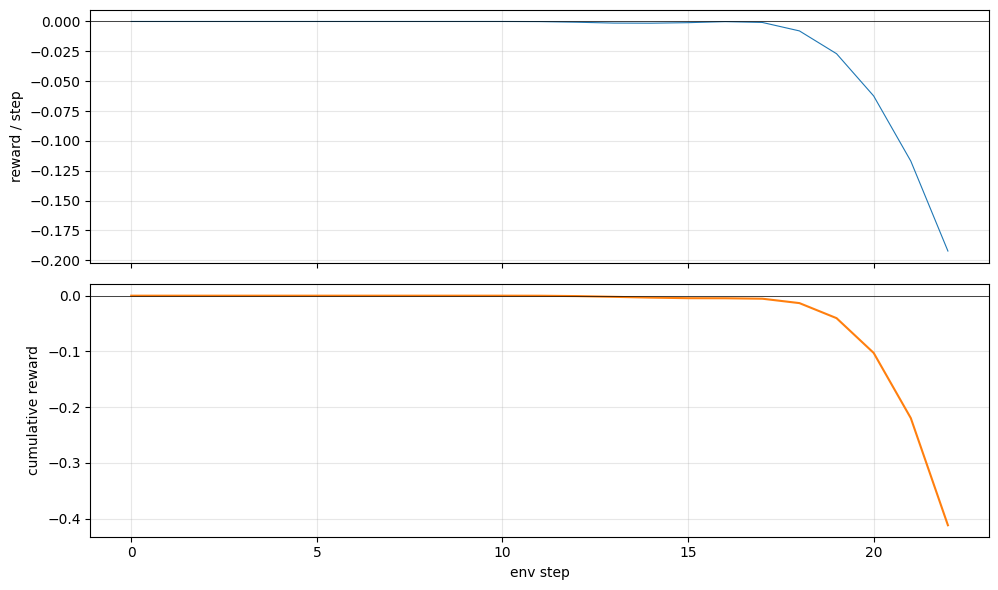

In [33]:
env = SimpleRewardEnv(
    n_targets=1,
    target_height=1.5,
    seed=42,
    max_episode_steps=1000,
    render_mode="human",
)

rewards = run_episode(env, model, render=True)
env.close()

plot_rewards(rewards)